# Descarga de corpus

In [1]:
# !gdown 1mE4dVNVqS1Xt28xz7ngHZrtGM0WTSrQ0

## Visualización del corpus

In [2]:
import pandas as pd

df = pd.read_csv("./noticias_unison.csv")

In [3]:
df

,url,titulo,fecha,autor,texto
0,https://www.unison.mx/nota/?idnoti=29404,Hay que imprimir un alto espíritu competitivo ...,02 de enero de 2020,Jesús Alberto Rubio,Es fundamental que a todo protagonista de cual...
1,https://www.unison.mx/nota/?idnoti=29405,Académico de la URS ingresa al Sistema Naciona...,02 de enero de 2020,Olivia Paredes,"Como resultado del esfuerzo, perseverancia y l..."
2,https://www.unison.mx/nota/?idnoti=29406,Búhos Todo Terreno apoyará a Centros Comunitar...,03 de enero de 2020,Jesús Alberto Rubio,Con el objetivo de continuar con la vinculació...
3,https://www.unison.mx/nota/?idnoti=29407,Buscará el Comité de Sustentabilidad de la URS...,03 de enero de 2020,Olivia Paredes,Para lograr mejores resultados respecto al cui...
4,https://www.unison.mx/nota/?idnoti=29408,Estudiantes del Campus Cajeme participaron en ...,04 de enero de 2020,Redacción,Alrededor de 50 estudiantes de los distintos p...
...,...,...,...,...,...
4230,https://www.unison.mx/nota/?idnoti=33860,Anuncia el grupo de Altas Energías del Difus e...,09 de marzo de 2023,Jesús Alberto Rubio,El próximo sábado el grupo de Altas Energías d...
4231,https://www.unison.mx/nota/?idnoti=33861,Participan alumnos del campus Caborca en conve...,09 de marzo de 2023,Haydee Gaxiola,"En el marco del Día Internacional de la Mujer,..."
4232,https://www.unison.mx/nota/?idnoti=33862,Maricielo Correa: desde Perú hasta la Universi...,09 de marzo de 2023,Paula Trespalacios Argain,Maricielo Correa Carrión llegó de Perú hace do...
4233,https://www.unison.mx/nota/?idnoti=33863,Realizan estudiantes la Ruta de la Sororidad c...,09 de marzo de 2023,Jesús Alberto Rubio,A través de la modalidad de conversatorio y en...


___

# Limpieza

## Configuración de SpaCy

In [4]:
import spacy

In [5]:
# !python -m spacy download es_core_news_md

In [12]:
spacy.prefer_gpu()
nlp = spacy.load("es_core_news_md")

## Función de limpieza

In [7]:
def clean_and_lemmatize(texts, disable_ner_parser=True):
    clean_texts = []
    for doc in nlp.pipe(texts, batch_size=2000, disable=["ner", "parser"] if disable_ner_parser else []):
        tokens = [
            token.lemma_.lower() 
            for token in doc 
            if not token.is_stop and token.is_alpha
        ]
        clean_texts.append(" ".join(tokens))
    return clean_texts

In [ ]:
df['texto'] = clean_and_lemmatize(df['texto'].astype(str))

In [11]:
df.to_csv("noticias_lematizadas.csv", index=False)

___

# Doc2Vec

In [9]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [14]:
texts = df["texto"].astype(str)

tagged_docs = [
    TaggedDocument(words=text.split(), tags=[str(i)])
    for i, text in enumerate(texts)
]

In [15]:
model = Doc2Vec(

    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=40

)

model.build_vocab(tagged_docs)

model.train(
    tagged_docs,
    total_examples=model.corpus_count,
    epochs=model.epochs
)

In [16]:
doc_vectors = [model.dv[str(i)] for i in range(len(df))]

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(doc_vectors)

df["cluster"] = clusters

___

## Nube de palabras

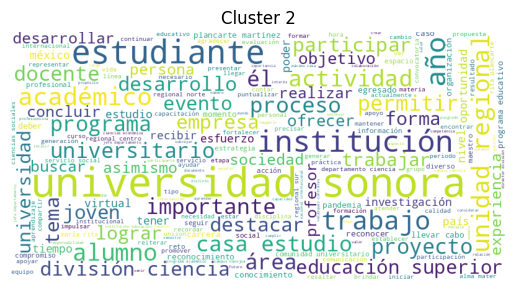

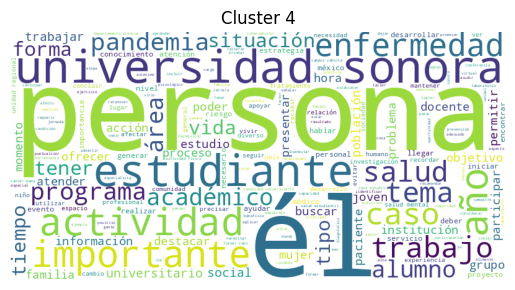

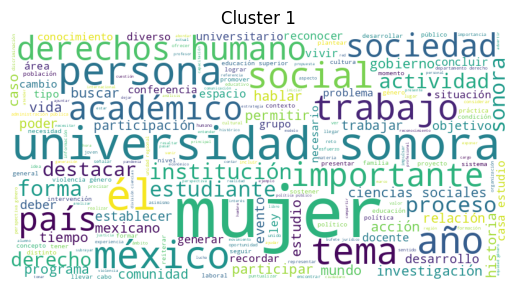

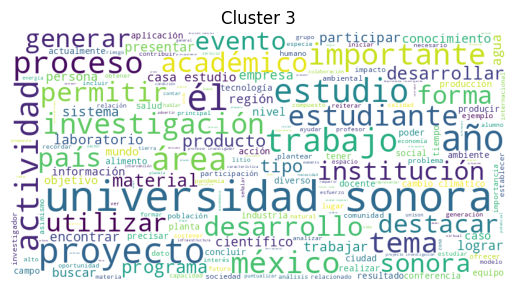

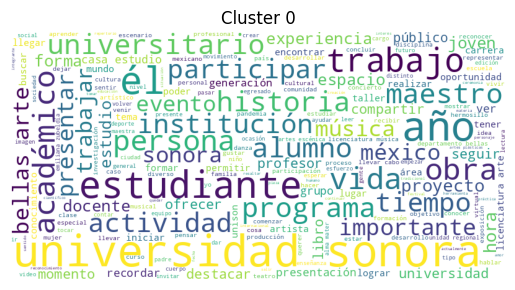

In [24]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

clusters = df["cluster"].unique()

for c in clusters:

    texts = df[df["cluster"] == c]["texto"]

    words = " ".join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(words)

    plt.figure()
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(f"Cluster {c}")
    plt.show()